In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    pipeline, 
    AutoTokenizer, 
    AutoModelForSeq2SeqLM, 
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments, 
    Seq2SeqTrainer,
    BertTokenizer, 
    BertForMaskedLM, 
    BertModel
)

import accelerate
from datasets import load_dataset, concatenate_datasets
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# from ragas.metrics import summarization_score
# from ragas import evaluate

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "/kaggle/input/models/luisrafaelajoc/summary-distilbart-12-6-output/transformers/default/1/summary-distilbart-12-6-output"
loaded_tokenizer = AutoTokenizer.from_pretrained(model_path)
loaded_model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [3]:
words = [
    "hello", "bye", "thanks", "sorry", "please",
    "yes", "no", "maybe", "sure", "okay",
    "meeting", "schedule", "tomorrow", "today", "later",
    "call", "text", "email", "discuss", "confirm"
]

In [4]:
def get_embedding(text):
    inputs = loaded_tokenizer(text, return_tensors="pt", truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = loaded_model(**inputs, output_hidden_states=True, return_dict=True)
    
    # Mean pooling
    embedding = outputs.encoder_last_hidden_state.mean(dim=1)
    return embedding.squeeze().numpy()

embeddings = [get_embedding(word) for word in words]

In [5]:
X = np.array(embeddings)
# X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

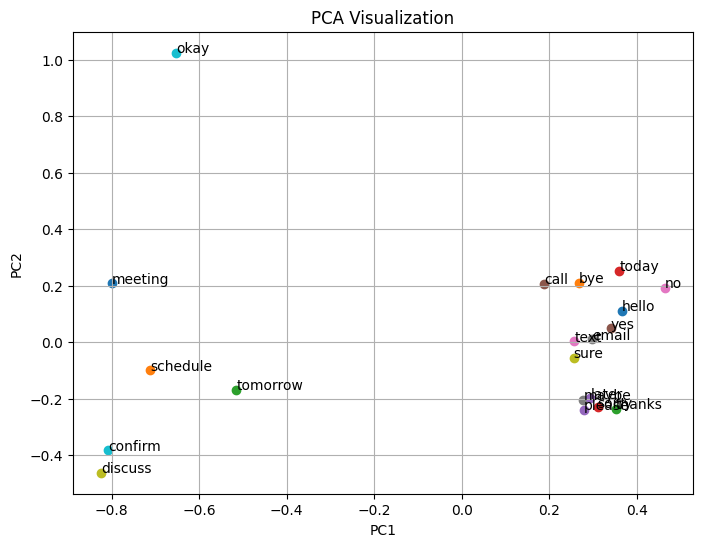

In [6]:
plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    x, y = X_pca[i]
    plt.scatter(x, y)
    plt.annotate(word, (x, y))

plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()